In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\Python Project\Customer Churn Analysis.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing blank with 0 as tenure is 0 and no total charges are recorded

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [14]:
df.duplicated().sum()

np.int64(0)

In [ ]:
def conv(value):
    if value ==1:
        return "yes"
    else:
        return"no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

#converted 0 and 1 values of senior citizen to yes/no to make it easier to understand.

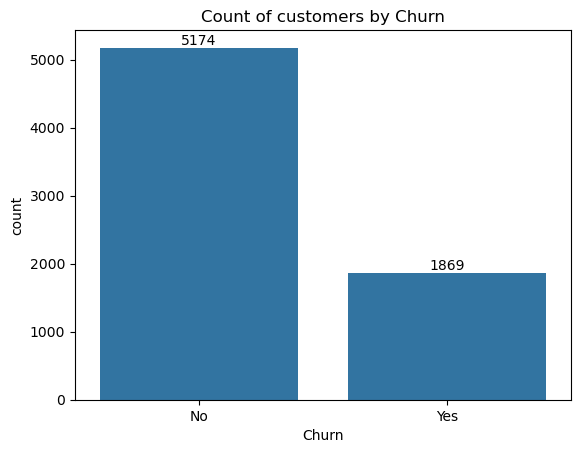

In [19]:
ax = sns.countplot(x='Churn' , data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

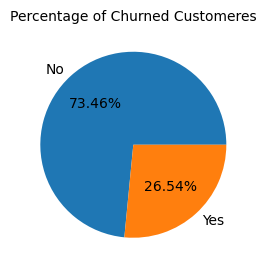

In [23]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customeres", fontsize = 10)
plt.show()

From the given pie chart we can conclude that 26.54% of our customers have churned out # not let's explore the reason behind it

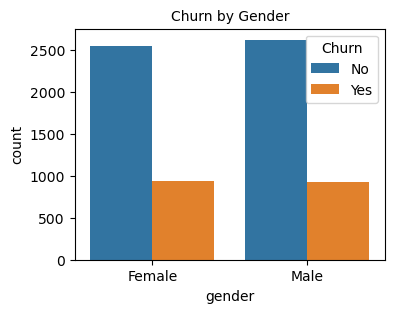

In [31]:
plt.figure(figsize = (4,3))
sns.countplot(x ='gender',data =df ,hue = "Churn")
plt.title("Churn by Gender", fontsize = 10)
plt.show()

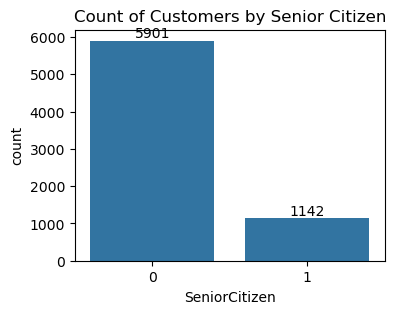

In [38]:
plt.figure(figsize = (4,3))
ax = sns.countplot(x ='SeniorCitizen',data =df )
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Senior Citizen" )
plt.show()

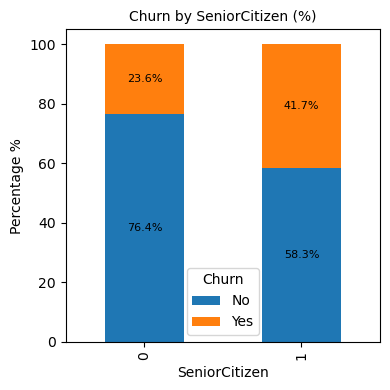

In [41]:
counts = pd.crosstab(df['SeniorCitizen'], df['Churn'])

#  Convert to percentage
percentage = counts.div(counts.sum(axis=1), axis=0) * 100

#  Plot stacked bar chart
ax = percentage.plot(kind='bar', stacked=True, figsize=(4,4))

#  Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

#  Titles & labels
plt.title("Churn by SeniorCitizen (%)", fontsize=10)
plt.ylabel("Percentage %")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

#Comparative a greater percentage of people in senior citizen category have churned

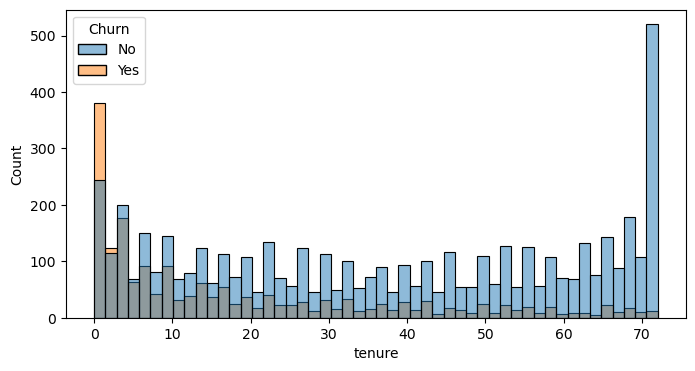

In [47]:
plt.figure(figsize = (8,4))
sns.histplot(x = "tenure", data=df, bins = 50, hue = 'Churn')
plt.show()

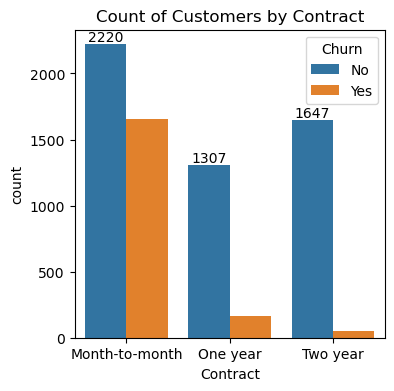

In [51]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ='Contract',data =df, hue = 'Churn') 
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Contract" )
plt.show()

#People who have month to month contract are likely to churn then from those who have 1 or 2 year or contract 

In [52]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

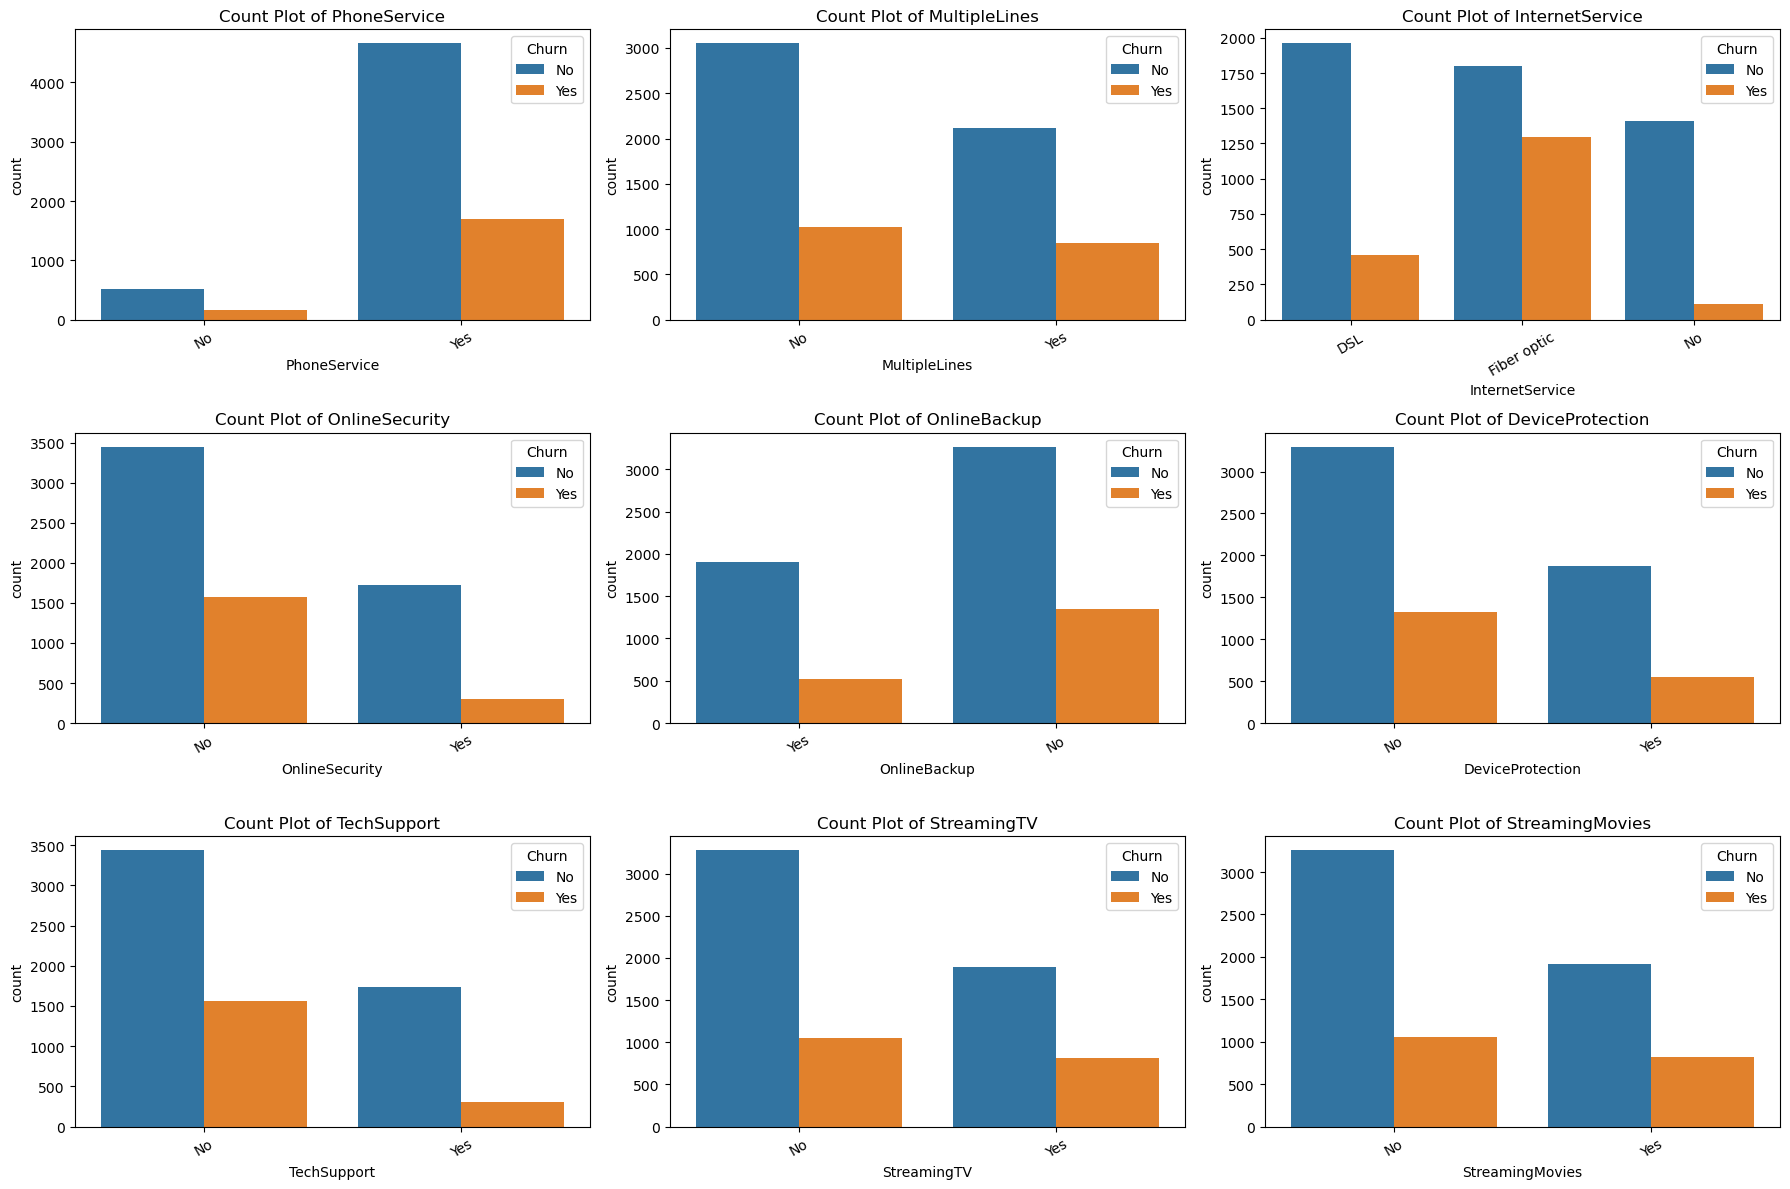

In [10]:
# -------------------------------
# 1. Columns list
# -------------------------------
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# -------------------------------
# 2. Data Cleaning
# -------------------------------
# Replace unwanted categories
for col in cols:
    df[col] = df[col].replace(['No internet service', 'No phone service'], 'No')




# -------------------------------
# 4. Subplots with Churn (Hue)
# -------------------------------
plt.figure(figsize=(18, 12))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, hue='Churn')
    plt.title("Count Plot of " + col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()




#The majority of customers who do not churn tend to have services like PhoneService, InternetServices(particularly DSL), and OnlineSecurity enbled. For services like OnlineServices, TechSupport, and Streaming TV churn rates are noticeably higher when these services are not used or are unavailable.

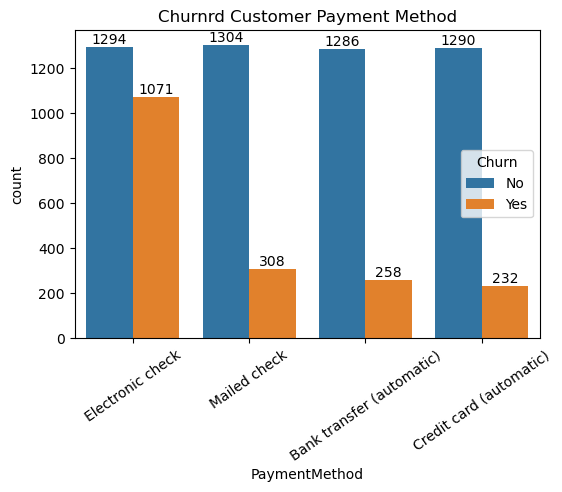

In [19]:
plt.figure(figsize = (6,4))
ax = sns.countplot(x ='PaymentMethod',data =df, hue = 'Churn') 
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churnrd Customer Payment Method" )
plt.xticks(rotation=35)
plt.show()

#Customer is likely to churn when he is using electronic check as a payment method.